# Delving Deep into Rectifiers: He Initialization from Scratch

This notebook studies **He initialization** (He et al., 2015) — the principled way to randomly initialize deep networks that use **ReLU / PReLU** activations.

**Paper:** [Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification](https://arxiv.org/abs/1502.01852)

We will implement activations and a deep MLP in NumPy, compare **He** vs **Xavier** initialization on a toy 2-D classification task, and visualize per-layer activation variance and gradient norms to see why He initialization keeps signal flow stable.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

## 2. Activations: ReLU and Parametric ReLU (PReLU)

In [2]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(z.dtype)

class PReLU:
    '''Parametric ReLU: f(z) = max(0,z) + a*min(0,z).
    The negative slope a is learned per channel (or shared).'''
    def __init__(self, channels, init=0.25, channel_shared=False):
        self.channel_shared = channel_shared
        self.a = np.full(1 if channel_shared else channels, init, dtype=np.float32)
    def forward(self, z):
        self.z = z
        return np.where(z > 0, z, self.a * z)
    def backward(self, grad_out):
        grad_z = np.where(self.z > 0, grad_out, self.a * grad_out)
        self.grad_a = np.where(self.z > 0, 0, grad_out * self.z).sum(axis=0)
        return grad_z
    def update(self, lr, momentum=0.9):
        if not hasattr(self, 'v'):
            self.v = np.zeros_like(self.a)
        self.v = momentum * self.v + lr * self.grad_a
        self.a -= self.v

## 3. Deep MLP with He / Xavier Initialization

In [3]:
class DeepMLP:
    def __init__(self, layer_sizes, init_mode='he', activation='relu', use_prelu=False, prelu_init=0.25):
        self.init_mode = init_mode.lower()
        self.use_prelu = use_prelu
        self.L = len(layer_sizes) - 1
        self.W = []
        self.b = []
        self.prelus = []
        for i in range(self.L):
            n_in, n_out = layer_sizes[i], layer_sizes[i+1]
            if self.init_mode == 'he':
                # He et al. 2015: preserve variance through ReLU/PReLU
                a = prelu_init if use_prelu else 0.0
                std = np.sqrt(2.0 / ((1.0 + a**2) * n_in))
            elif self.init_mode == 'xavier':
                # Glorot & Bengio 2010: assumes linear activations
                std = np.sqrt(1.0 / n_in)
            else:
                std = 0.01
            self.W.append(np.random.randn(n_in, n_out).astype(np.float32) * std)
            self.b.append(np.zeros(n_out, dtype=np.float32))
            # No activation after final layer
            if use_prelu and i < self.L - 1:
                self.prelus.append(PReLU(n_out, init=prelu_init))
            else:
                self.prelus.append(None)

    def forward(self, X, store=True):
        z = X
        self.activations = [z] if store else None
        self.zs = [] if store else None
        for i in range(self.L):
            z = z @ self.W[i] + self.b[i]
            if store: self.zs.append(z)
            if i < self.L - 1:
                if self.use_prelu and self.prelus[i] is not None:
                    z = self.prelus[i].forward(z)
                else:
                    z = relu(z)
            if store: self.activations.append(z)
        return z

    def backward(self, grad_logits):
        grads_W = [None] * self.L
        grads_b = [None] * self.L
        grad = grad_logits
        for i in range(self.L - 1, -1, -1):
            grads_b[i] = grad.sum(axis=0)
            grads_W[i] = self.activations[i].T @ grad
            if i > 0:
                grad = grad @ self.W[i].T
                if self.use_prelu and self.prelus[i-1] is not None:
                    grad = self.prelus[i-1].backward(grad)
                else:
                    grad = grad * relu_derivative(self.zs[i-1])
        return grads_W, grads_b

    def update(self, grads_W, grads_b, lr):
        for i in range(self.L):
            self.W[i] -= lr * grads_W[i]
            self.b[i] -= lr * grads_b[i]
            if self.use_prelu and self.prelus[i] is not None:
                self.prelus[i].update(lr)

## 4. Toy Dataset: Moons

In [4]:
X, y = make_moons(n_samples=2000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)
Y_train_oh = np.eye(2)[y_train].astype(np.float32)
Y_test_oh = np.eye(2)[y_test].astype(np.float32)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (1600, 2), Test: (400, 2)


## 5. Training Helpers

In [5]:
def softmax(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def cross_entropy_loss(logits, y_oh):
    probs = softmax(logits)
    return -np.mean(np.log(probs[range(len(y_oh)), y_oh.argmax(axis=1)] + 1e-9))

def accuracy(logits, y):
    preds = softmax(logits).argmax(axis=1)
    return (preds == y).mean()

def signal_flow_snapshot(net, X, Y_oh):
    '''Return per-layer activation variance and per-layer gradient norm.'''
    logits = net.forward(X, store=True)
    probs = softmax(logits)
    grad = (probs - Y_oh) / len(X)
    grads_W, _ = net.backward(grad)
    act_vars = [float(np.var(a)) for a in net.activations[:-1]]
    grad_norms = [float(np.linalg.norm(g)) for g in grads_W]
    return act_vars, grad_norms

def train(net, X, Y, X_val, Y_val, y_val, epochs=100, lr=0.05, batch_size=64, snapshot_every=10):
    history = {'train_loss':[], 'val_loss':[], 'val_acc':[], 'act_var':[], 'grad_norm':[]}
    n = X.shape[0]
    for epoch in range(epochs):
        perm = np.random.permutation(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            logits = net.forward(X[idx])
            probs = softmax(logits)
            grad = (probs - Y[idx]) / len(idx)
            grads_W, grads_b = net.backward(grad)
            net.update(grads_W, grads_b, lr)
        # end-of-epoch metrics
        if epoch % snapshot_every == 0 or epoch == epochs - 1:
            act_vars, grad_norms = signal_flow_snapshot(net, X[:512], Y[:512])
            history['act_var'].append((epoch, act_vars))
            history['grad_norm'].append((epoch, grad_norms))
        train_logits = net.forward(X, store=False)
        val_logits = net.forward(X_val, store=False)
        history['train_loss'].append(cross_entropy_loss(train_logits, Y))
        history['val_loss'].append(cross_entropy_loss(val_logits, Y_val))
        history['val_acc'].append(accuracy(val_logits, y_val))
    return history

## 6. Experiment: 10-Layer ReLU Network (He vs Xavier)

In [6]:
layer_sizes = [2] + [64]*9 + [2]  # 10 weight layers
epochs = 100
lr = 0.05

net_he  = DeepMLP(layer_sizes, init_mode='he')
net_xav = DeepMLP(layer_sizes, init_mode='xavier')

hist_he  = train(net_he,  X_train, Y_train_oh, X_test, Y_test_oh, y_test, epochs=epochs, lr=lr)
hist_xav = train(net_xav, X_train, Y_train_oh, X_test, Y_test_oh, y_test, epochs=epochs, lr=lr)

print(f'He    final val acc: {hist_he["val_acc"][-1]:.4f}')
print(f'Xavier final val acc: {hist_xav["val_acc"][-1]:.4f}')

He    final val acc: 0.9725
Xavier final val acc: 0.9725


## 7. Loss and Accuracy Curves

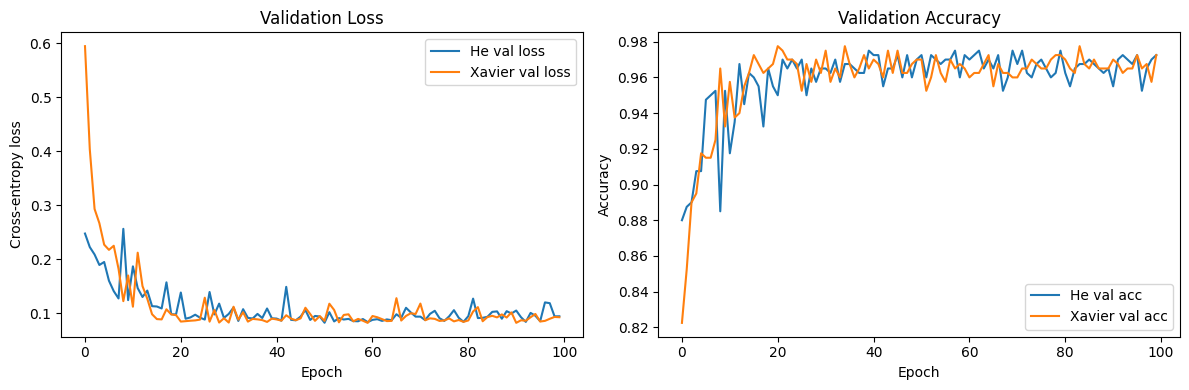

In [7]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(hist_he['val_loss'], label='He val loss')
plt.plot(hist_xav['val_loss'], label='Xavier val loss')
plt.xlabel('Epoch'); plt.ylabel('Cross-entropy loss'); plt.legend(); plt.title('Validation Loss')
plt.subplot(1,2,2)
plt.plot(hist_he['val_acc'], label='He val acc')
plt.plot(hist_xav['val_acc'], label='Xavier val acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Validation Accuracy')
plt.tight_layout(); plt.show()

## 8. Per-Layer Activation Variance

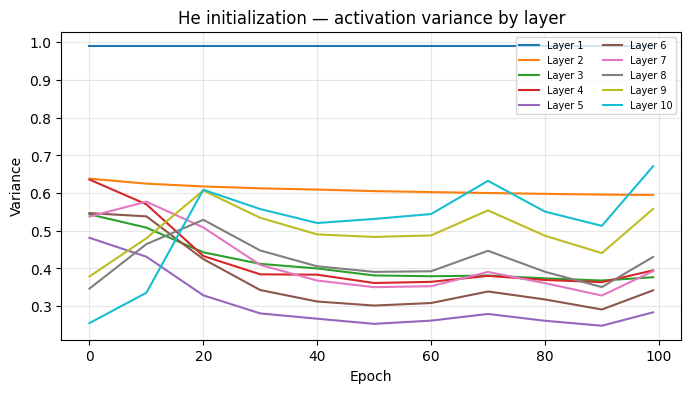

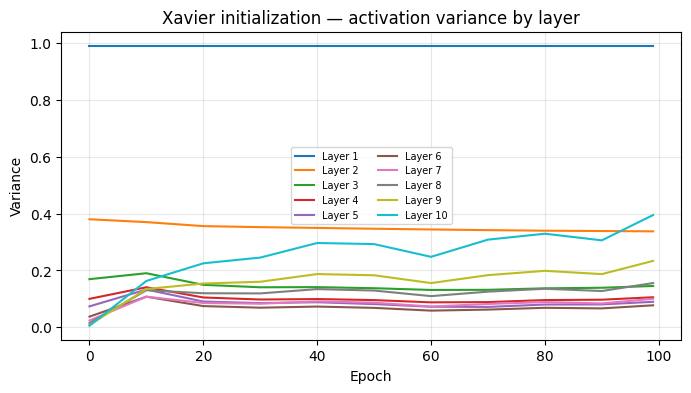

In [8]:
def plot_snapshots(hist, key, title, log=False):
    epochs, lists = zip(*hist[key])
    mat = np.array(lists)
    plt.figure(figsize=(8,4))
    for li in range(mat.shape[1]):
        y = mat[:, li]
        if log:
            plt.semilogy(epochs, y, label=f'Layer {li+1}')
        else:
            plt.plot(epochs, y, label=f'Layer {li+1}')
    plt.xlabel('Epoch'); plt.ylabel('Variance'); plt.title(title)
    plt.legend(ncol=2, fontsize=7); plt.grid(True, alpha=0.3); plt.show()

plot_snapshots(hist_he,  'act_var', 'He initialization — activation variance by layer')
plot_snapshots(hist_xav, 'act_var', 'Xavier initialization — activation variance by layer')

## 9. Per-Layer Gradient Norms

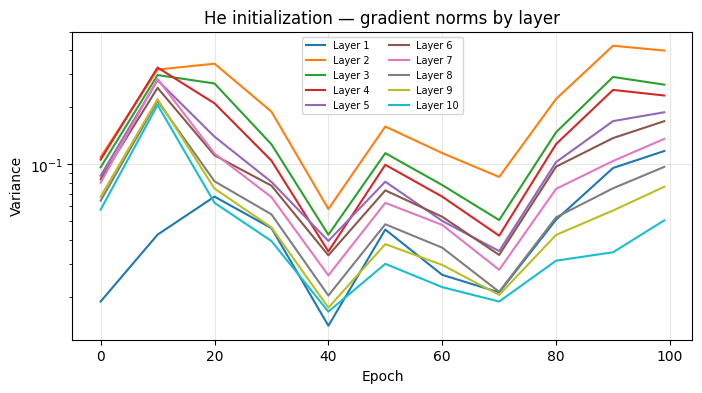

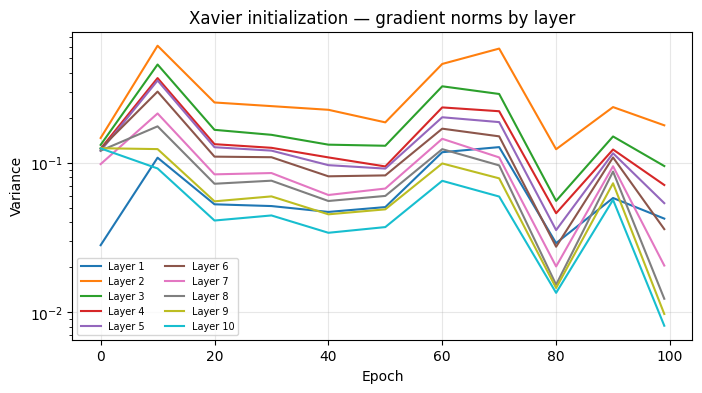

In [9]:
plot_snapshots(hist_he,  'grad_norm', 'He initialization — gradient norms by layer', log=True)
plot_snapshots(hist_xav, 'grad_norm', 'Xavier initialization — gradient norms by layer', log=True)

## 10. Deeper Stress Test: 20 Layers

In [10]:
for depth in [10, 20]:
    sizes = [2] + [64]*(depth-1) + [2]
    h_he  = train(DeepMLP(sizes, init_mode='he'),  X_train, Y_train_oh, X_test, Y_test_oh, y_test, epochs=30, lr=lr)
    h_xav = train(DeepMLP(sizes, init_mode='xavier'), X_train, Y_train_oh, X_test, Y_test_oh, y_test, epochs=30, lr=lr)
    print(f'Depth {depth:2d}: He={h_he["val_acc"][-1]:.4f}, Xavier={h_xav["val_acc"][-1]:.4f}')

Depth 10: He=0.9725, Xavier=0.9525


Depth 20: He=0.9725, Xavier=0.9550


## 11. Optional: PReLU with He-Style Init

In [11]:
# PReLU introduces an extra slope a on negative inputs. He init becomes std = sqrt(2/((1+a^2)*fan_in)).
net_prelu = DeepMLP([2]+[64]*9+[2], init_mode='he', use_prelu=True, prelu_init=0.25)
hist_prelu = train(net_prelu, X_train, Y_train_oh, X_test, Y_test_oh, y_test, epochs=80, lr=0.05)
print('PReLU final val acc:', hist_prelu['val_acc'][-1])

PReLU final val acc: 0.965


## 12. Summary

In [12]:
print('He initialization recap:')
print('  ReLU  : W ~ N(0, 2/fan_in)')
print('  PReLU : W ~ N(0, 2/((1+a^2)*fan_in))')
print('  This preserves activation variance and gradient magnitudes through many layers.')
print('  In deep ReLU nets, He init trains faster and reaches higher accuracy than Xavier init.')

He initialization recap:
  ReLU  : W ~ N(0, 2/fan_in)
  PReLU : W ~ N(0, 2/((1+a^2)*fan_in))
  This preserves activation variance and gradient magnitudes through many layers.
  In deep ReLU nets, He init trains faster and reaches higher accuracy than Xavier init.
